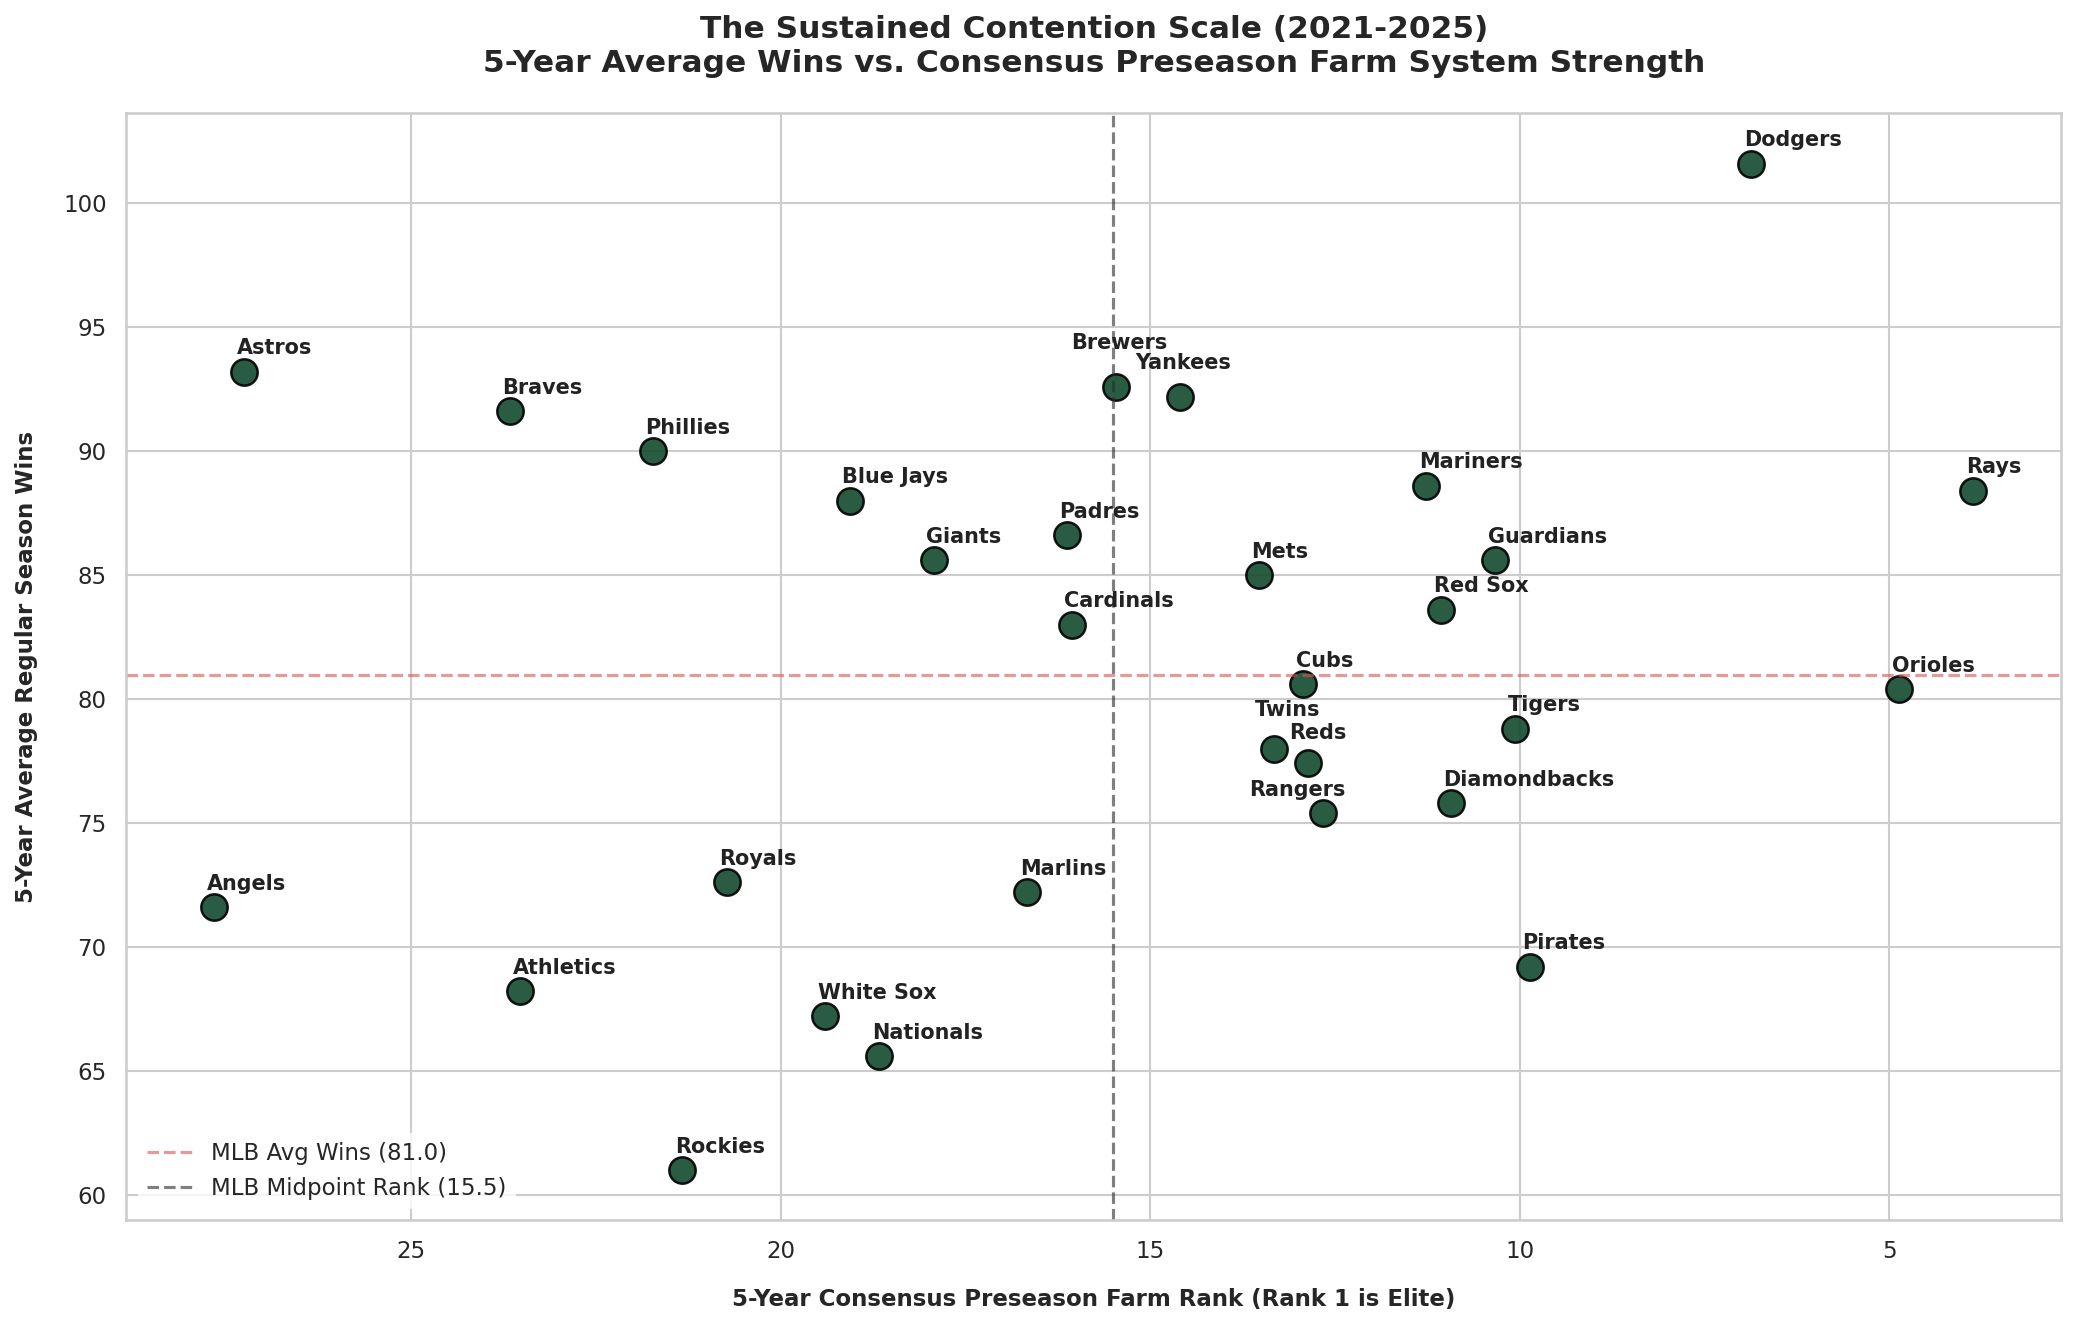

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# DataFrame is named 'df_raw'
df_raw = pd.read_csv('mlb_farm_data.csv', header=1)

# Clean column names by stripping whitespace
df_raw.columns = df_raw.columns.str.strip()

# 1. Calculate the exact average for each row across all 3 platforms
df_raw['Yearly_Consensus'] = df_raw[['Rank_BA', 'Rank_FG', 'Rank_Pipeline']].mean(axis=1)

# 2. Group by Team and collapse the 5-year data into mathematical averages
df_final = df_raw.groupby(['Team', 'Avg_Wins'])['Yearly_Consensus'].mean().reset_index()
df_final.rename(columns={'Yearly_Consensus': 'Avg_Consensus_Farm_Rank'}, inplace=True)

# 3. Visualization
plt.figure(figsize=(14, 9), dpi=150)
sns.set_theme(style="whitegrid")

# Create the high-res scatter plot
ax = sns.scatterplot(
    data=df_final,
    x='Avg_Consensus_Farm_Rank',
    y='Avg_Wins',
    s=160,
    color='#134a2e',  # Clean ballpark green
    edgecolor='black',
    alpha=0.9,
    linewidth=1.2
)

# Invert X-axis so consensus rank #1 sits on the premium right side
plt.gca().invert_xaxis()

# 4. Generate dynamic quadrant dividing lines based on data averages
win_mean = df_final['Avg_Wins'].mean()
plt.axhline(y=win_mean, color='#d9534f', linestyle='--', alpha=0.6, linewidth=1.5, label=f'MLB Avg Wins ({win_mean:.1f})')
plt.axvline(x=15.5, color='#292b2c', linestyle='--', alpha=0.6, linewidth=1.5, label='MLB Midpoint Rank (15.5)')

# 5. Label every team dot clearly with a slight physical offset
for i in range(len(df_final)):
    team_name = df_final['Team'].iloc[i]
    x_offset = 0.1  # Default x-offset, decreased to move text slightly right
    y_offset = 0.7   # Default y-offset, increased by 0.1 to raise labels further

    # Custom offsets for problematic teams
    if team_name == 'Brewers': # Separate condition for Brewers to keep its x_offset
        x_offset = 0.6
        y_offset = 1.5
    elif team_name == 'Twins':
        x_offset = 0.25  # Decreased by 0.05 from 0.3
        y_offset = 1.3   # Decreased by 0.1 from 1.4
    elif team_name == 'Yankees': # Separate condition for Yankees
        x_offset = 0.6  # Further decreased by 0.2 from 0.8 to move right on inverted axis
        y_offset = 1.1   # Decreased by 0.1 from 1.2
    elif team_name == 'Reds': # Separate condition for Reds
        x_offset = 0.25  # Decreased by 0.05 from 0.3
        y_offset = 1.0   # Decreased by 0.1 from 1.1
    elif team_name == 'Rangers':
        x_offset = 1.0 # Decreased to move text slightly right
        y_offset = 0.7 # Decreased by 0.1 from 0.8

    plt.text(
        df_final['Avg_Consensus_Farm_Rank'].iloc[i] + x_offset,
        df_final['Avg_Wins'].iloc[i] + y_offset,
        team_name,
        horizontalalignment='left',
        size='small',
        weight='bold',
        color='#222222'
    )

# Chart Labels, Aesthetics, and Padding
plt.title('The Sustained Contention Scale (2021-2025)\n5-Year Average Wins vs. Consensus Preseason Farm System Strength', fontsize=15, pad=20, weight='bold')
plt.xlabel('5-Year Consensus Preseason Farm Rank (Rank 1 is Elite)', fontsize=11, labelpad=12, weight='semibold')
plt.ylabel('5-Year Average Regular Season Wins', fontsize=11, labelpad=12, weight='semibold')
plt.legend(loc='lower left', frameon=True, facecolor='white', edgecolor='none')
plt.tight_layout()

# Display the graphic
plt.show()